In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


df_raw= pd.read_csv("/Users/chris/Desktop/ChristianBDA2026/data/symbol_info_3-25.csv")

df = df_raw[
    (df_raw["is_etf"] == 0) &
    (df_raw["is_fund"] == 0) &
    (df_raw["is_actively_trading"] == 1) &
    (df_raw["market_cap"] > 0) &
    (df_raw["total_revenue"] > 0)
].copy()
df["market_cap_b"] = df["market_cap"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df = df.replace([np.inf, -np.inf], np.nan)

Histogram with 'market_cap'
 - 30 bin                                                                      
  - Colore a scelta                                                             
  - Linea mediana (arancione tratteggiata)
  - Linea media (rossa punteggiata)                                             
  - Titolo che descrive la forma della distribuzione
  - Spine pulite                                                                
  - Label formattate (es. 246.2B)
                                       




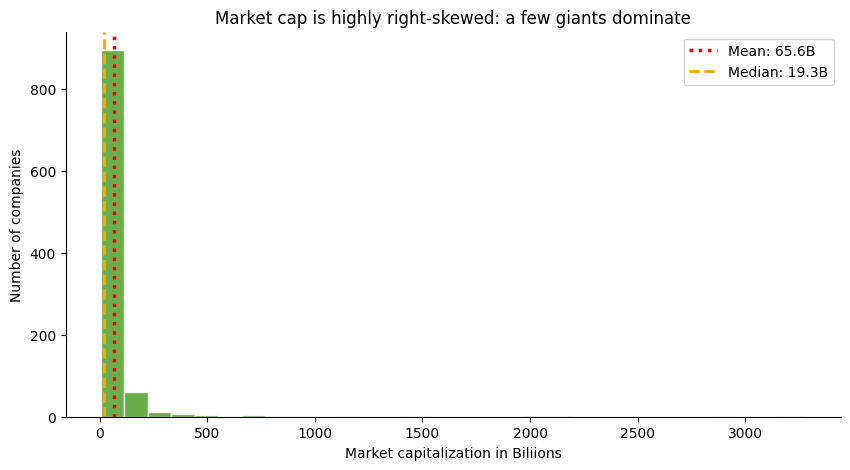

In [21]:
cap = df['market_cap_b'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    cap,
    bins = 30,
    color = '#4f9f2c',
    edgecolor = 'White',
    alpha = 0.85
)

cap_mean = cap.mean()
cap_median = cap.median()

ax.axvline(cap_mean, color = 'Red', linestyle = ':', linewidth = 2.5, label = f'Mean: {cap_mean:,.1f}B' )
ax.axvline(cap_median, color = 'Orange', linestyle = '--', linewidth = 2, label = f'Median: {cap_median:,.1f}B' )

ax.legend()
ax.set_title('Market cap is highly right-skewed: a few giants dominate')
ax.set_xlabel('Market capitalization in Biliions')
ax.set_ylabel('Number of companies')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()